In [ ]:
!pip install ultralytics
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow # Especial para Colab

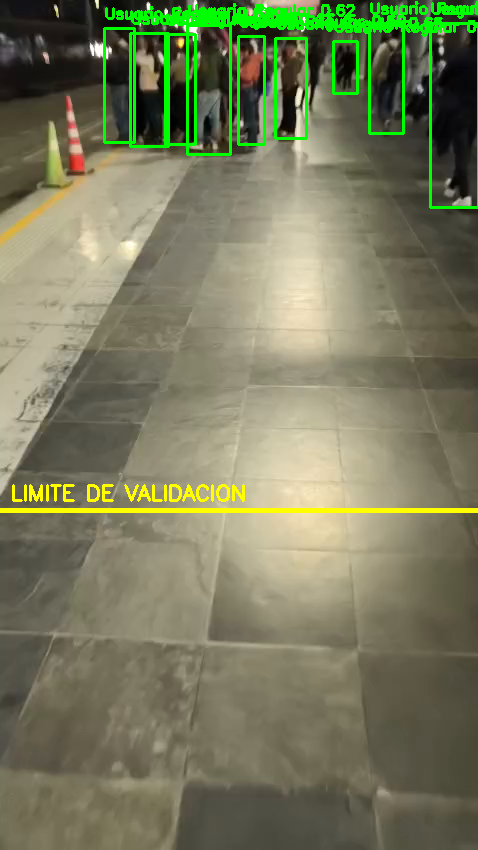

In [5]:

# 1. Carga del modelo entrenado o baseline
model = YOLO('yolov8n.pt')

def procesar_seguridad_sitp(video_path, line_y_threshold=0.6):
    """
    Simula el monitoreo de una zona crítica (torniquete/puerta).
    line_y_threshold: Porcentaje de la altura del frame donde está la 'línea de no retorno'.
    """
    cap = cv2.VideoCapture(video_path)

    # Obtener dimensiones para definir la ROI
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    limit_line = int(height * line_y_threshold)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Inferencia con YOLOv8
        results = model.predict(frame, conf=0.4, verbose=False)

        # Dibujar línea de seguridad (Visualización del Baseline)
        cv2.line(frame, (0, limit_line), (width, limit_line), (0, 255, 255), 3)
        cv2.putText(frame, "LIMITE DE VALIDACION", (10, limit_line - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        for box in results[0].boxes:
            # Extraer coordenadas y clase
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            conf = float(box.conf[0])

            if model.names[cls] == 'person':
                color = (0, 255, 0) # Verde por defecto
                label = "Usuario Regular"

                # Lógica de detección de evasión:
                # Si la base de la persona (y2) cruza la línea sin validación
                if y2 > limit_line:
                    color = (0, 0, 255) # Rojo: Alerta
                    label = "ALERTA: POSIBLE EVASION"
                    # Aquí es donde el sistema genera el log para el 'Registro de Flujo'

                # Dibujar Bounding Box personalizado
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, f"{label} {conf:.2f}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # En Colab, mostrar frames puede ser lento, se recomienda procesar y guardar
        # o usar cv2_imshow para una muestra
        cv2_imshow(frame)
        break # Rompemos para demostración en un solo frame

    cap.release()

# Ejecución (Sube un clip de tus datasets de Roboflow/UCF-Crime)
procesar_seguridad_sitp('WhatsApp Video 2026-04-10 at 7.31.53 PM.mp4')
